In [1]:
# ===================== SEED FC EXCERCISE =====================
!pip install nilearn
import os
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.stats import zscore
from nilearn.image import concat_imgs


# ============================
# Clone entire Github repository
# ============================

!git clone https://github.com/gpreti/EE-629.git

print("Repository cloned.") #everything exist locally now, path: "EE-629/EX1/"

# ============================
# When using Google Drive
# ============================
#from google.colab import drive
#drive.mount('/content/drive')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 39.4 MB/s eta 0:00:00
Cloning into 'EE-629'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (140/140), done.
remote: Total 166 (delta 50), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (166/166), 69.69 MiB | 16.20 MiB/s, done.
Resolving deltas: 100% (50/50), done.
Repository cloned.


In [2]:
!ls EE-629/EX1/DATA

fMRI_vols  PCCL_ROI.nii  TCS.mat	  yeo_labels.mat
GM.nii	   PCC_ROI.nii	 yeo_labels8.mat


In [3]:
# ===================== LOAD AND CONCATENATE 3D TO 4D FMRI VOLUMES =====================
# Path to your 3D fMRI volumes
fmri_folder = "EE-629/EX1/DATA/fMRI_vols/"

# List all NIfTI files (make sure they are sorted in time order)
volumes = sorted([
    os.path.join(fmri_folder, f)
    for f in os.listdir(fmri_folder)
    if f.endswith('.nii') or f.endswith('.nii.gz')
])


# Concatenate all 3D volumes into a 4D image
fmri_4d = concat_imgs(volumes)

# Check shape
print("4D fMRI shape:", fmri_4d.shape)

4D fMRI shape: (91, 109, 91, 30)


In [4]:
import numpy as np
from nilearn import image, masking
from nilearn.input_data import NiftiSpheresMasker

# --- Parameters ---
pcc_coords = [(0, -52, 26)]  # MNI coordinates of ventral PCC
radius = 6  # mm

# --- Load your functional volume ---
func_file = fmri_4d # already in MNI space

# --- Create the sphere mask and extract time series ---
masker = NiftiSpheresMasker(seeds=pcc_coords,
                             radius=radius,
                             standardize=True,   # optional, z-score the time series
                             detrend=True,       # remove linear trend
                             #low_pass=0.1,
                             #high_pass=0.01,
                             t_r=0.72)

pcc_ts = masker.fit_transform(func_file)  # shape = (n_timepoints, 1)
print(pcc_ts.shape)
pcc_ts_var=pcc_ts.flatten()


/tmp/ipython-input-264/1601102714.py:3: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  from nilearn.input_data import NiftiSpheresMasker
/tmp/ipython-input-264/1601102714.py:21: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  pcc_ts = masker.fit_transform(func_file)  # shape = (n_timepoints, 1)


(30, 1)


In [5]:
pcc_ts_var.shape

(30,)

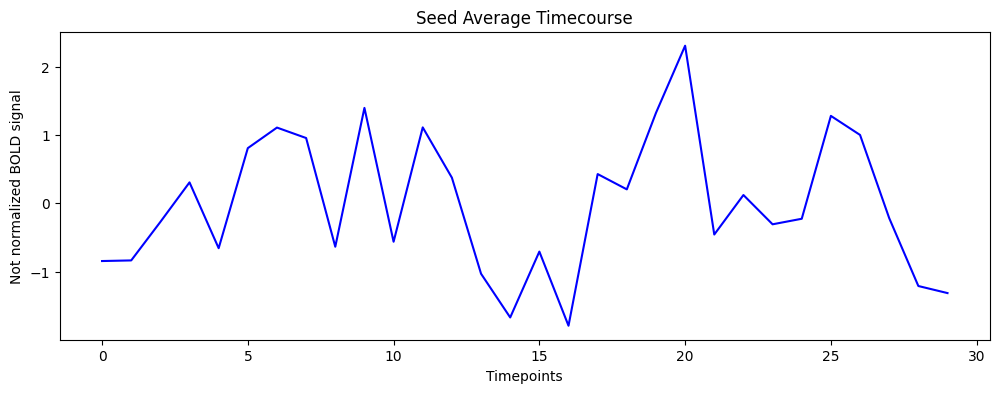

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(pcc_ts, color='blue')
plt.xlabel('Timepoints')
plt.ylabel('Not normalized BOLD signal')
plt.title('Seed Average Timecourse')
plt.show()


In [28]:
V0_img=fmri_4d;

# ===================== UPLOAD FILES =====================
path_exercise='EE-629/EX1/'
# NIFTI files
out_file = os.path.join(path_exercise, 'RESULTS/Corr.nii')
roi_file  = os.path.join(path_exercise, 'DATA/PCC_ROI.nii')    # 3D NIfTI seed mask
mask_file = os.path.join(path_exercise, 'DATA/GM.nii')             # 3D NIfTI Gray Matter mask
# ===================== LOAD DATA =====================
#V0_img = nib.load(fmri_file)
V0 = V0_img.get_fdata()          # shape: (x, y, z, time)
n_timepoints = V0.shape[3]

roi_img = nib.load(roi_file)
roi = roi_img.get_fdata()  > 0    # shape: (x, y, z)


mask_img = nib.load(mask_file)
mask = mask_img.get_fdata() > .3      # shape: (x, y, z), thresholded at .3 (probability map)

In [29]:
print(roi.shape)
print(mask.shape)
print(V0.shape)
n_timepoints

(91, 109, 91)
(91, 109, 91)
(91, 109, 91, 30)


30

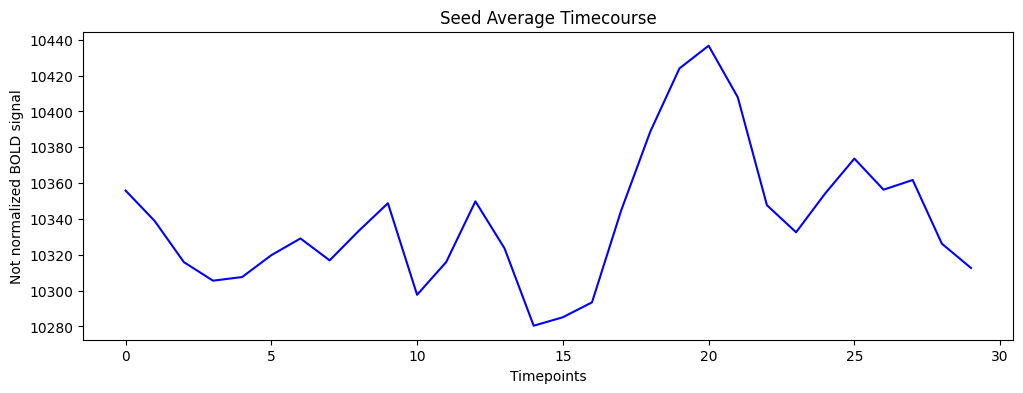

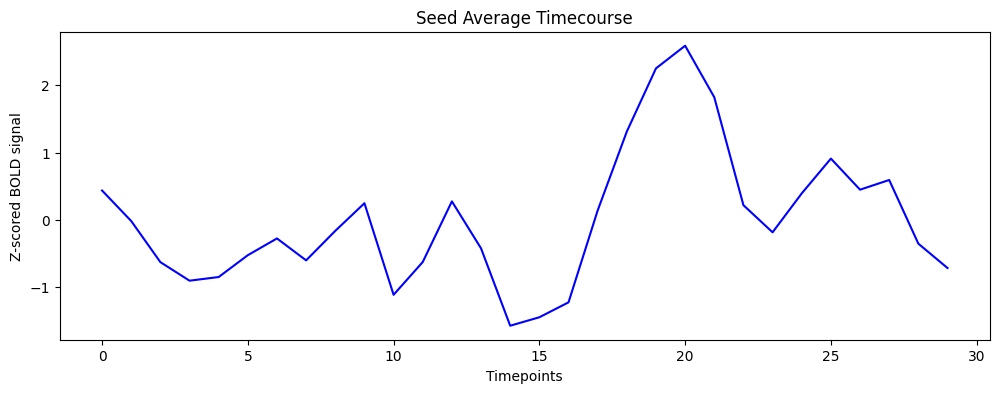

In [30]:
# ===================== COMPUTE SEED TIMECOURSE =====================
def compute_seed_tc(V0, roi):
    dx, dy, dz, n_time = V0.shape
    V0_flat = V0.reshape(-1, n_time)          # (voxels, time)
    roi_flat = roi.flatten() > 0            # seed voxels
    tc_seed = V0_flat[roi_flat].mean(axis=0)
    return tc_seed

# intersection between roi and GM mask
roi_gm_mask = roi & mask

tc_seed = compute_seed_tc(V0, roi_gm_mask)
seed_tc_z = (tc_seed - tc_seed.mean()) / tc_seed.std() #optional z-scoring for visualization

# ===================== PLOT SEED TIMECOURSE =====================

plt.figure(figsize=(12, 4))
plt.plot(tc_seed, color='blue')
plt.xlabel('Timepoints')
plt.ylabel('Not normalized BOLD signal')
plt.title('Seed Average Timecourse')
plt.show()

# ===================== PLOT z scored SEED TIMECOURSE =====================

plt.figure(figsize=(12, 4))
plt.plot(seed_tc_z, color='blue')
plt.xlabel('Timepoints')
plt.ylabel('Z-scored BOLD signal')
plt.title('Seed Average Timecourse')
plt.show()



In [31]:
def seed_correlation_map(V0, tc_seed, gm_mask):
    """
    Compute seed-based correlation map restricted to a gray matter mask.

    Parameters
    ----------
    V0 : np.ndarray
        4D fMRI data of shape (X, Y, Z, T)
        X, Y, Z = spatial dimensions
        T = number of timepoints

    tc_seed : np.ndarray
        1D array of seed timecourse, shape (T,)
        Can be extracted from a ROI or sphere.

    gm_mask : np.ndarray
        3D binary mask of shape (X, Y, Z)
        Only voxels where gm_mask > 0 will be included in computation.

    Returns
    -------
    Corr : np.ndarray
        3D correlation map, shape (X, Y, Z)
        Voxel values correspond to Pearson correlation with seed.
        Voxels outside gm_mask are set to 0.
    """

    # z-score voxel timecourses across time
    zV0 = zscore(V0, axis=3, ddof=1)  # shape (X,Y,Z,T)

    # z-score seed
    ztc = zscore(tc_seed, ddof=1)     # shape (T,)

    # Flatten GM mask
    gm_indices = gm_mask > 0          # boolean mask
    V0_flat = zV0[gm_indices]         # shape (n_voxels_in_mask, T)

    # replicate seed timecourse to match voxel array
    mat_seed = np.tile(ztc, (V0_flat.shape[0], 1))  # shape (n_voxels_in_mask, T)

    # compute Pearson correlation per voxel
    corr_flat = np.sum(V0_flat * mat_seed, axis=1) / (V0.shape[3] - 1)  # shape (n_voxels_in_mask,)

    # put back into 3D
    Corr = np.zeros(V0.shape[:3])       # shape (X,Y,Z)
    Corr[gm_indices] = corr_flat        # assign correlation to GM voxels

    return Corr


In [32]:

Corr = seed_correlation_map(V0, tc_seed, mask)

# ===================== SAVE CORRELATION MAP =====================
Corr_img = nib.Nifti1Image(Corr, affine=V0_img.affine, header=V0_img.header)
out_file = os.path.join(path_exercise, 'RESULTS/Corr.nii')
nib.save(Corr_img, out_file)
print(f'Correlation map saved to {out_file}')

Correlation map saved to EE-629/EX1/RESULTS/Corr.nii


In [27]:
from google.colab import files

files.download(out_file)  # download your Corr file to be checked with a NIFTI viewer


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>